# Laboratorio Aprendizaje Automático para Clasificación

En este laboratorio, exploraremos cómo utilizar dos algoritmos de aprendizaje supervisado, Random Forest y Support Vector Machines (SVM), para la clasificación de imágenes. Utilizaremos un conjunto de datos proporcionado por kaggle y realizaremos una serie de pasos para preprocesar los datos, entrenar los modelos y evaluar su rendimiento. Además, recordaremos algunos de los modelos de extracción manual de características vistos durante el primer módulo del curso y su impacto al momento de entrenar un modelo de clasificación.

In [1]:
codigo_estudiante = 202423300 #TU CÓDIGO DE ESTUDIANTE UNIANDES

## Importante!

Antes de realizar el laboratorio, comprueba que tu código de estudiante esté registrado en la base de datos de autocalificación del curso. Si tu código no está registrado por favor comunícate con el equipo docente.

### Nota: 
La siguiente celda puede tardar en correr, ya que también prepara el entorno de laboratorio

In [2]:
from lm import search_code

if search_code(codigo_estudiante) == True:
    print('Su código de estudiante esta REGISTRADO')
else:
    print('Su código de estudiante NO ESTA REGISTRADO. Comuníquese por favor con el equipo docente')

Su código de estudiante esta REGISTRADO


## 1. Preparación del entorno

Primero, importamos las bibliotecas necesarias.

#### ¿Qué es sklearn?
**sklearn** es una librería de Python que proporciona herramientas simples y eficientes para el análisis de datos y el modelado predictivo. Es ampliamente utilizada en el ámbito del aprendizaje automático (Machine Learning) debido a su simplicidad y facilidad de uso.

#### Utilidad en Modelos de Aprendizaje Automático

- **Modelos Incluidos:** sklearn incluye una variedad de modelos de aprendizaje automático, como regresión, clasificación, clustering y reducción de dimensionalidad.
- **Pipeline Completo:** Facilita todo el pipeline del aprendizaje automático desde el preprocesamiento de datos hasta la evaluación del modelo.

#### Funcionamiento de los Modelos

- **Entrenamiento del Modelo:** La función `.fit()` se utiliza para entrenar un modelo en un conjunto de datos.
- **Predicción:** La función `.predict()` se utiliza para realizar predicciones sobre nuevos datos una vez que el modelo ha sido entrenado.

#### Herramientas Importantes

1. **Modelos de Machine Learning:**
   - `RandomForestClassifier`, `SVC`, `LinearRegression`, entre otros.
2. **Preprocesamiento de Datos:**
   - `StandardScaler`, `MinMaxScaler`, `LabelEncoder`.
3. **Evaluación de Modelos:**
   - Métricas como `accuracy_score`, `classification_report`, `confusion_matrix`.

In [3]:
import numpy as np
import lm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import os
import glob
from PIL import Image
from tqdm import tqdm

print("Se importaron todos los paquetes necesarios para este laboratorio.")

Se importaron todos los paquetes necesarios para este laboratorio.


## 2. Cargar dataset
El dataset que usaremos en este laboratorio fue obtenido de [kaggle](https://www.kaggle.com/datasets/niteshfre/chessman-image-dataset) y corresponde a un conjunto de imágenes de las seis fichas encontradas en el ajedrez. Te invitamos a explorar el dataset y destacar la variabilidad de los colores, la iluminación y demás elementos de las imágenes. Observando manualmente algunos ejemplares del dataset encontrarás también que para una misma clase, dos imágenes cuentan con distintos aspectos y fondos, lo cual incrementa la complejidad para nuestros modelos.

In [4]:
# Definir el directorio base del dataset
base_dir = 'chessman-image-dataset/Chess/'

# Inicializar listas para imágenes y etiquetas
images = []
labels = []

# Etiquetas de las clases
classes = os.listdir(base_dir)
sample_images = {}

print(f"Cargando dataset {base_dir}")
# Cargar imágenes y etiquetas
for label in classes:
    class_dir = os.path.join(base_dir, label)
    for img_path in tqdm(glob.glob(os.path.join(class_dir, '*'))):
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((128, 128))  # Redimensionar las imágenes si es necesario
            img = np.array(img)
            images.append(img)
            labels.append(label)
            if label not in sample_images.keys():
                sample_images[label] = img
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

# Convertir a numpy arrays
images = np.array(images)
labels = np.array(labels)
# Crea un arreglo con los indices de tomas las imágenes para más adelante hacer la división de los datos sobre estos valores.
indices = np.arange(len(images))

Cargando dataset chessman-image-dataset/Chess/


100%|██████████| 102/102 [00:01<00:00, 51.42it/s]


Ahora dividimos los datos en el conjunto de entrenamiento y de evaluación:

In [5]:
# Dividir en conjuntos de entrenamiento, validación y prueba
X_train_indices, X_test_indices = train_test_split(indices, test_size=0.2, stratify=labels, random_state=42)
X_train = images[X_train_indices]
y_train = labels[X_train_indices]

X_test = images[X_test_indices]
y_test = labels[X_test_indices]

print(f'Tamaño del conjunto de entrenamiento: {len(X_train)}')
print(f'Tamaño del conjunto de prueba: {len(X_test)}')

# Verifica las dimensiones
print(f'Dimensiones de las imágenes: {X_train[0].shape}')

Tamaño del conjunto de entrenamiento: 444
Tamaño del conjunto de prueba: 112
Dimensiones de las imágenes: (128, 128, 3)


## 3. Visualizar datos

Visualización del dataset:


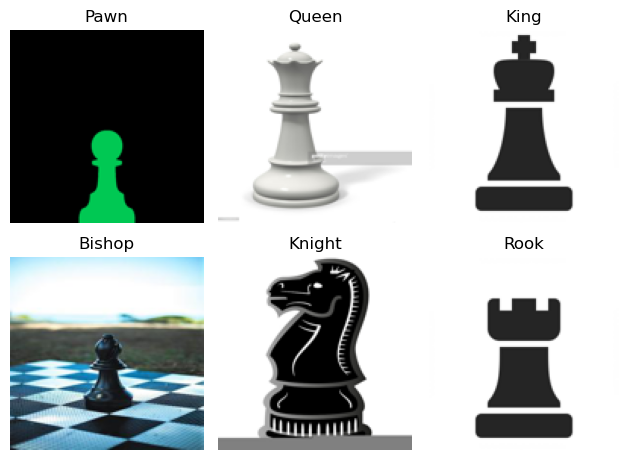

In [6]:
print("Visualización del dataset:")
# Mostramos algunas imágenes del dataset
fig, axes = plt.subplots(2, 3)
for ax, cls in zip(axes.flatten(), classes):
    random_img = sample_images[cls]
    ax.imshow(random_img)
    ax.set_title(cls)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Entrenamiento del modelo Random Forest

A continuación, entrenaremos un modelo de Random Forest utilizando los datos de entrenamiento. Sugerimos revisar la documentación en [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier) para entender a mayor profundidad su funcionamiento y los parámetros con los que puedes experimentar.

La siguiente celda presenta algunos de los parámetros de Random Forest estudiados en el curso. Te invitamos a pensar en cómo estos parámetros podrían afectar el resultado del modelo. 

In [7]:
# Parámetros para modelo Random Forest
n_estimators = 10000 
min_samples_split = 2
bootstrap = True

Tanto el modelo de Random Forest, como el de SVM de sklearn requieren entradas de una dimensión. Por esto aplanaremos las imágenes para representar los datos con los vectores de sus intensidades.

In [8]:
# Ajustar las entradas para Random Forest
print(f"Tamaño inicial del arreglo de train: {X_train.shape}")
## Aplanar las imágenes para ingresar vectores a los modelos de clasificación
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
print(f"Tamaño del arreglo de train tras aplanar las imágenes: {X_train_flat.shape}")

Tamaño inicial del arreglo de train: (444, 128, 128, 3)
Tamaño del arreglo de train tras aplanar las imágenes: (444, 49152)


In [9]:
# Inicializar y entrenar Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=n_estimators, 
    min_samples_split=min_samples_split, 
    bootstrap=bootstrap,
    random_state=42
    )

rf_clf.fit(X_train_flat, y_train)
# Evaluar el modelo
y_pred_rf = rf_clf.predict(X_test_flat)
print("Random Forest - Conjunto de evaluación")
print(classification_report(y_test, y_pred_rf, target_names=classes))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest - Conjunto de evaluación
              precision    recall  f1-score   support

        Pawn       0.43      0.35      0.39        17
       Queen       0.20      0.20      0.20        15
        King       0.57      0.57      0.57        21
      Bishop       0.38      0.36      0.37        22
      Knight       0.26      0.31      0.29        16
        Rook       0.32      0.33      0.33        21

    accuracy                           0.37       112
   macro avg       0.36      0.36      0.36       112
weighted avg       0.37      0.37      0.37       112

Accuracy: 0.36607142857142855


### Visualizando resultados aleatorios de predicciones de Random Forest

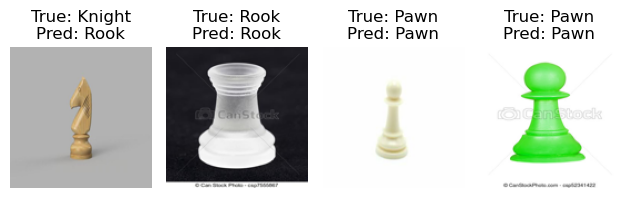

In [10]:
indices = np.random.choice(len(X_test), 4, replace=False)

# Crear un subplot 2x3 para mostrar las imágenes
fig, axes = plt.subplots(1, 4)

for i, ax in enumerate(axes):
    idx = indices[i]
    img = X_test[idx].reshape(128, 128, 3)
    true_label = y_test[idx]
    pred_label = y_pred_rf[idx]
    
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Entrenamiento del modelo SVM para clasificación
A continuación, entrenaremos un modelo de Support Vector Machines (SVM) utilizando los datos de entrenamiento. Sugerimos revisar la documentación en [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC) para entender a mayor profundidad su funcionamiento y los parámetros con los que puedes experimentar.

La siguiente celda presenta algunos de los parámetros de SVM estudiados en el curso. Te invitamos a pensar cómo pueden afectar estos parámetros al desempeño del modelo.

In [11]:
# Parámetros para modelo Support Vector Machines
kernel_type = 'linear'
regularization_C = 1.0

In [12]:
# Entrenar SVM
svm_clf = SVC(kernel=kernel_type, random_state=42, C=regularization_C)
svm_clf.fit(X_train_flat, y_train)
y_pred_svm = svm_clf.predict(X_test_flat)
print("SVM - Test")
print(classification_report(y_test, y_pred_svm, target_names=classes))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM - Test
              precision    recall  f1-score   support

        Pawn       0.19      0.24      0.21        17
       Queen       0.21      0.27      0.24        15
        King       0.59      0.48      0.53        21
      Bishop       0.25      0.23      0.24        22
      Knight       0.07      0.06      0.07        16
        Rook       0.19      0.19      0.19        21

    accuracy                           0.25       112
   macro avg       0.25      0.24      0.24       112
weighted avg       0.26      0.25      0.25       112

Accuracy: 0.25


### Visualizando resultados aleatorios de predicciones de SVM

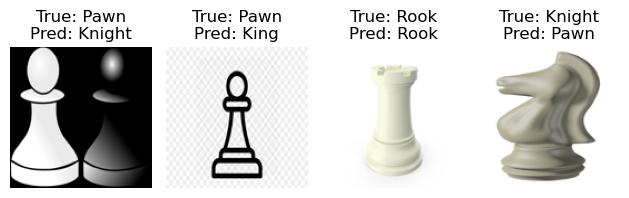

In [13]:
indices = np.random.choice(len(X_test), 4, replace=False)

# Crear un subplot 2x3 para mostrar las imágenes
fig, axes = plt.subplots(1, 4)

for i, ax in enumerate(axes):
    idx = indices[i]
    img = X_test[idx].reshape(128, 128, 3)
    true_label = y_test[idx]
    pred_label = y_pred_svm[idx]
    
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Trabajo individual: explorando nuevas representaciones de los datos
En la primera exploración de los clasificadores Random Forest y SVM, estos modelos buscaron categorizar las imágenes a partir de sus matrices de intensidades aplanadas. Ahora, explora clasificar las imágenes aplicando un preprocesamiento de los datos para obtener otros tipos de representaciones mediante la extracción manual de características.

A continuación te presentamos un ejemplo de cómo se extraen los histogramas HOG y su visualización. Este procedimiento te puede guiar en la extracción de HOG como descriptor para el entrenamiento de un clasificador:

Visualización de características:


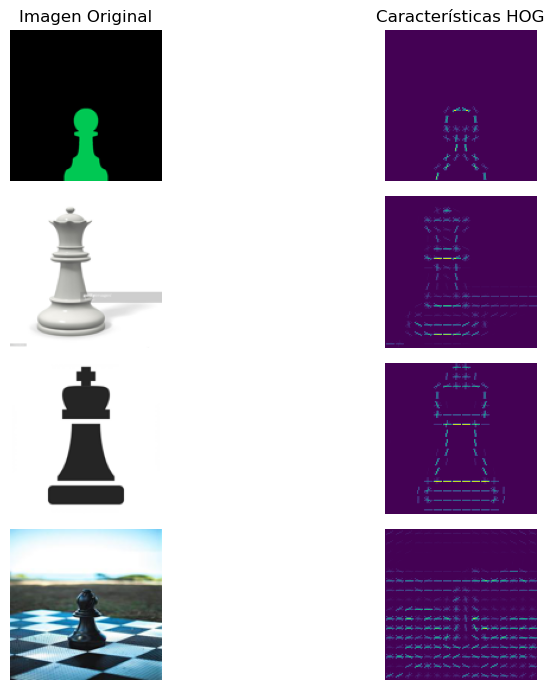

In [14]:
from skimage.feature import hog
from skimage import color

print("Visualización de características:")
# Mostramos algunas imágenes del dataset
fig, ax = plt.subplots(4, 2, figsize=(10, 7))
for i in range(len(classes[2:])):
    img = sample_images[classes[i]]
    gray_img = color.rgb2gray(img)
    
    # HOG
    # Revisa la documentación de la función para entender la utilidad de cada parámetro y cómo obtener los vectores en lugar de la visualización de HOG
    ft_vec, hog_feature = hog(gray_img, pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2), feature_vector=True, visualize=True)
    
    ax[i, 0].imshow(img)
    ax[i, 0].axis('off')

    ax[i, 1].imshow(hog_feature)
    ax[i, 1].axis('off')

    # Agregar títulos a las columnas
    if i == 0:
        ax[i, 0].set_title("Imagen Original")
        ax[i, 1].set_title("Características HOG")

plt.tight_layout()
plt.show()

## Extracción de características: histogramas de color y HOG
Usa la función `hog()` de skimage.feature para extraer los vectores de características HOG de las imágenes. Recuerda que para obtener los histogramas HOG las imágenes deben presentarse en **escala de grises**.
Además, para el caso de la representación por color se extraerán los histogramas de color concatenados para cada una de las imágenes. De esta manera, la extracción de características resultará en arreglos de una sola dimensión que pueden ser procesados por los modelos de RF y de SVM.

In [15]:
# se recorre el arreglo "images" para obtener los vectores que describirán sus características HOG y de color. Para obtener la representación de HOG sigue el algoritmo presentado en el ejemplo anterior y asegúrate de que el argumento visualize sea False, ya que requieres los histogramas, pero no visualizarlos.

# Guarda los vectores individuales en las listas "hog_features" y "color_features":
# Extracción de características HOG e intensidades de color
hog_features = []
color_features = []

# Recorre cada una de las imágenes en el dataset completo para obtener su respectivo vector de características de HOG y de histogramas de color concatenados.
for img in images:
    # Completa el código para obtener y guardar el vector de HOG y el de histogramas de color concatenados en las listas adecuadas:
    # Convertir a escala de grises
    gray_img = color.rgb2gray(img)
    
    # Extraer características HOG y almacenarlas en la lista de "hog_features"
    
    
    # TODO: ¡Atención! Aquí debes obtener las características HOG como en el ejemplo de la celda anterior.
    #COMPLETA DESDE AQUÍ
    hog_feature = hog(gray_img, 
                     pixels_per_cell=(8, 8), 
                     cells_per_block=(2, 2), 
                     feature_vector=True, 
                     visualize=False) # Reemplaza "None" por el código asociado a la función hog() de skimage.feature.
    #COMPLETA HASTA AQUÍ
    
    
    hog_features.append(hog_feature.tolist())
    # Extraer un histogramas de color por cada canal, concatenarlos como un único vector por imagen en "hist_feature" y almacenarlo en la lista de "color_features".
    hist_feature = []
    for channel in range(3):
        hist, _ = np.histogram(img[:, :, channel], bins=256, range=(0, 256))
        hist_feature.extend(hist.tolist())
    color_features.append(hist_feature)
    
    # ¡Atención!
    # Asegúrate de que cada elemento que agregues a las listas hog_features y a color_features respectivamente sean listas de una sola dimensión,
    # de modo que al final de esta celda obtengas para cada uno de ellos un arreglo de arreglos unidimensionales.

# Convertir a numpy arrays
hog_features = np.array(hog_features)
color_features = np.array(color_features)

print("Extracción de características finalizada. Los vectores de características están almacenados en 'hog_features' y 'color_features', respectivamente.")

Extracción de características finalizada. Los vectores de características están almacenados en 'hog_features' y 'color_features', respectivamente.


In [16]:
# Revisando los resultados de tu ejecución y guardando respuestas
assert len(hog_features[0].shape) == 1, "Error en la obtención de los vectores de características de HOG. Los vectores no cumplen con las dimensiones establecidas."
assert len(hog_features) == 556, "Error en la obtención de los vectores de características de HOG. Los vectores no cumplen con las dimensiones establecidas."
assert len(color_features[0].shape) == 1, "Error en la obtención de los vectores de características de color. Los vectores no cumplen con las dimensiones establecidas."
assert len(color_features) == 556, "Error en la obtención de los vectores de características de color. Los vectores no cumplen con las dimensiones establecidas."
lm.verify_and_save(1, hog_features, codigo_estudiante)


## Entrenamiento y evaluación de RF con HOG e histogramas concatenados de colores

Antes de explorar el uso de los clasificadores con nuestros nuevos descriptores dividiremos nuestros vectores de características en los sets de entrenamiento y evaluación respetando la división de datos seguida en los anteriores modelos.

**¡Atención!** Recuerda usar el parámetro random_state=42 y los mismos parámetros de los ejemplos al declarar cada modelo que se requiera en las siguientes fases del laboratorio.

In [17]:
X_train_hog_fts = hog_features[X_train_indices]
X_test_hog_fts = hog_features[X_test_indices]

X_train_color_fts = color_features[X_train_indices]
X_test_color_fts = color_features[X_test_indices]

#### Vectores de HOG

Completa el código faltante en la siguiente celda para construir el modelo en la variable `rf_clf_HOG` y entrenarlo con las **características HOG de las imágenes**. **Importante!** No olvides emplear los mismos parámetros que en el ejemplo inicial, para que los resultados sean reproducibles. 

In [18]:
# Inicializar y entrenar Random Forest con características HOG
# TODO: declara el modelo Random Forest en la variable "rf_clf_HOG" y entrenalo con los vectores de características del set de entrenamiento. Recuerda que debes tomar como ejemplo el código con el que declaramos y entrenamos un RF al inicio del laboratorio.

#COMPLETA DESDE AQUÍ
rf_clf_HOG = RandomForestClassifier(
    n_estimators=n_estimators, 
    min_samples_split=min_samples_split, 
    bootstrap=bootstrap,
    random_state=42
) # Reemplaza "None" por el código asociado a la función RandomForestClassifier de sklearn.ensemble.
#COMPLETA HASTA AQUÍ


rf_clf_HOG.fit(X_train_hog_fts, y_train)

RandomForestClassifier(n_estimators=10000, random_state=42)

In [19]:
# Revisando los resultados de tu ejecución y guardando tu respuesta
assert isinstance(rf_clf_HOG, RandomForestClassifier), "El modelo rf_clf_HOG no ha sido correctamente declarado como una instancia de RandomForestClassifier."
lm.verify_and_save(2, rf_clf_HOG, codigo_estudiante)


Además, obtén las predicciones sobre el set de evaluación en la variable `y_pred_rf_HOG`.

In [20]:
# Evaluar el modelo
# TODO: obten las predicciones del modelo entrenado "rf_clf_HOG" para el set de evaluación en la variable "y_pred_rf_HOG".

#COMPLETA DESDE AQUÍ
y_pred_rf_HOG = rf_clf_HOG.predict(X_test_hog_fts) # Reemplaza "None" por el código asociado a la obtención de predicciones del modelo previamente entrenado.
#COMPLETA HASTA AQUÍ

In [21]:
# Revisando los resultados de tu ejecución y guardando tu respuesta
assert len(y_pred_rf_HOG) == len(X_test_hog_fts), f"El número de predicciones ({len(y_pred_rf_HOG)}) no coincide con el número de muestras en el conjunto de prueba ({len(X_test_hog_fts)})."
lm.verify_and_save(3, y_pred_rf_HOG, codigo_estudiante)

In [22]:
# Calcular métricas
print("Random Forest, HOG features - Conjunto de evaluación")
print(classification_report(y_test, y_pred_rf_HOG, target_names=classes))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_HOG))

Random Forest, HOG features - Conjunto de evaluación
              precision    recall  f1-score   support

        Pawn       0.69      0.53      0.60        17
       Queen       0.55      0.40      0.46        15
        King       0.61      0.67      0.64        21
      Bishop       0.46      0.73      0.56        22
      Knight       0.41      0.44      0.42        16
        Rook       0.77      0.48      0.59        21

    accuracy                           0.55       112
   macro avg       0.58      0.54      0.55       112
weighted avg       0.59      0.55      0.55       112

Accuracy: 0.5535714285714286


#### Vectores de histogramas concatenados

Completa el código faltante en la siguiente celda para construir el modelo en la variable `rf_clf_color_hist` y entrenarlo con las **los vectores de histogramas concatenados de las imágenes**. **Importante:** No olvides emplear los mismos parámetros que en el ejemplo inicial para que los resultados sean reproducibles

In [23]:
# Inicializar y entrenar Random Forest con características de color.
# TODO: declara el modelo Random Forest en la variable "rf_clf_color_hist" y entrenalo con los vectores de características del set de entrenamiento. Recuerda que debes tomar como ejemplo el código con el que declaramos y entrenamos un RF al inicio del laboratorio.

#COMPLETA DESDE AQUÍ
rf_clf_color_hist = RandomForestClassifier(
    n_estimators=n_estimators, 
    min_samples_split=min_samples_split, 
    bootstrap=bootstrap,
    random_state=42
) # Reemplaza "None" por el código asociado a la función RandomForestClassifier de sklearn.ensemble.
#COMPLETA HASTA AQUÍ

rf_clf_color_hist.fit(X_train_color_fts, y_train)


RandomForestClassifier(n_estimators=10000, random_state=42)

In [24]:
# Revisando los resultados de tu ejecución y guardando tu respuesta
assert isinstance(rf_clf_color_hist, RandomForestClassifier), "El modelo rf_clf_HOG no ha sido correctamente declarado como una instancia de RandomForestClassifier."
lm.verify_and_save(4, rf_clf_color_hist, codigo_estudiante)

Ahora obtén las predicciones sobre el set de evaluación en la variable `y_pred_rf_color_hist`. 

In [25]:
# Evaluar el modelo
# TODO: obten las predicciones del modelo entrenado "rf_clf_color_hist" para el set de evaluación en la variable "y_pred_rf_color_hist".

#COMPLETA DESDE AQUÍ
y_pred_rf_color_hist = rf_clf_color_hist.predict(X_test_color_fts) # Reemplaza "None" por el código asociado a la obtención de predicciones del modelo previamente entrenado.
#COMPLETA HASTA AQUÍ


In [26]:
# Revisando los resultados de tu ejecución y guardando tu respuesta
assert len(y_pred_rf_color_hist) == len(X_test_color_fts), f"El número de predicciones ({len(y_pred_rf_color_hist)}) no coincide con el número de muestras en el conjunto de prueba ({len(X_test_color_fts)})."
lm.verify_and_save(5, y_pred_rf_color_hist, codigo_estudiante)

In [27]:
# Calcular métricas
print("Random Forest, concatenated color histograms features - Conjunto de evaluación")
print(classification_report(y_test, y_pred_rf_color_hist, target_names=classes))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_color_hist))

Random Forest, concatenated color histograms features - Conjunto de evaluación
              precision    recall  f1-score   support

        Pawn       0.05      0.06      0.06        17
       Queen       0.14      0.07      0.09        15
        King       0.26      0.38      0.31        21
      Bishop       0.25      0.32      0.28        22
      Knight       0.20      0.12      0.15        16
        Rook       0.18      0.14      0.16        21

    accuracy                           0.20       112
   macro avg       0.18      0.18      0.17       112
weighted avg       0.19      0.20      0.18       112

Accuracy: 0.19642857142857142


## Entrenamiento y evaluación de SVM con HOG e histogramas concatenados de colores

En las siguientes celdas realiza el código para declarar, entrenar y evaluar el modelo de SVM usando (A) los vectores con la representación HOG y (B) los histogramas concatenados de las imágenes. **Importante:** recuerda usar los mismos parámetros del ejemplo para que el resultado sea reproducible

**(A) Representación de los datos: HOG**

In [29]:
# Inicializar y entrenar SVM con características de HOG.
# TODO: declara el modelo SVM en la variable "svm_clf_HOG" y entrenalo con los vectores de características del set de entrenamiento. Recuerda que debes tomar como ejemplo el código con el que declaramos y entrenamos un modelo SVM al inicio del laboratorio.
# Entrenar SVM
#COMPLETA DESDE AQUÍ
svm_clf_HOG = SVC(kernel=kernel_type, random_state=42, C=regularization_C)# Reemplaza "None" por el código asociado a la función SVC de sklearn.svm.
#COMPLETA HASTA AQUÍ


svm_clf_HOG.fit(X_train_hog_fts, y_train)

SVC(kernel='linear', random_state=42)

In [30]:

# Revisando los resultados de tu ejecución y guardando tus respuestas
assert isinstance(svm_clf_HOG, SVC), "El modelo svm_clf_HOG no ha sido correctamente declarado como una instancia de Support Vector Machines."
lm.verify_and_save(6, svm_clf_HOG, codigo_estudiante)

In [31]:
# Evaluar el modelo
# TODO: obten las predicciones del modelo entrenado "svm_clf_HOG" para el set de evaluación en la variable "y_pred_svm_HOG"
#COMPLETA DESDE AQUÍ
y_pred_svm_HOG = svm_clf_HOG.predict(X_test_hog_fts) # Reemplaza "None" por el código asociado a la obtención de predicciones del modelo previamente entrenado.
#COMPLETA HASTA AQUÍ

In [32]:

# Revisando los resultados de tu ejecución y guardando tus respuestas
assert len(y_pred_svm_HOG) == len(X_test_hog_fts), f"El número de predicciones ({len(y_pred_svm_HOG)}) no coincide con el número de muestras en el conjunto de prueba ({len(X_test_hog_fts)})."
lm.verify_and_save(7, y_pred_svm_HOG, codigo_estudiante)

In [33]:
# Evalúa el desempeño sobre el set de test.
print("SVM, HOG features - Test")
print(classification_report(y_test, y_pred_svm_HOG, target_names=classes))
print("Accuracy:", accuracy_score(y_test, y_pred_svm_HOG))

SVM, HOG features - Test
              precision    recall  f1-score   support

        Pawn       0.52      0.65      0.58        17
       Queen       0.38      0.33      0.36        15
        King       0.79      0.52      0.63        21
      Bishop       0.55      0.82      0.65        22
      Knight       0.43      0.56      0.49        16
        Rook       0.70      0.33      0.45        21

    accuracy                           0.54       112
   macro avg       0.56      0.54      0.53       112
weighted avg       0.58      0.54      0.54       112

Accuracy: 0.5446428571428571


**(B) Representación de los datos: Histogramas de colores concatenados**

In [36]:
# Inicializar y entrenar SVM con características de HOG.
# TODO: declara el modelo SVM en la variable "svm_clf_color_hist" y entrenalo con los vectores de características del set de entrenamiento. Recuerda que debes tomar como ejemplo el código con el que declaramos y entrenamos un modelo SVM al inicio del laboratorio.
# Entrenar SVM
#COMPLETA DESDE AQUÍ
svm_clf_color_hist = SVC(kernel=kernel_type, random_state=42, C=regularization_C) # Reemplaza "None" por el código asociado a la función SVC de sklearn.svm.
#COMPLETA HASTA AQUÍ

svm_clf_color_hist.fit(X_train_color_fts, y_train)

SVC(kernel='linear', random_state=42)

In [37]:
# Revisando los resultados de tu ejecución y guardando tus respuestas
assert isinstance(svm_clf_color_hist, SVC), "El modelo svm_clf_color_hist no ha sido correctamente declarado como una instancia de Support Vector Machines."
lm.verify_and_save(8, svm_clf_color_hist, codigo_estudiante)

In [38]:
# Evaluar el modelo
# TODO: obten las predicciones del modelo entrenado "svm_clf_color_hist" para el set de evaluación en la variable "y_pred_svm_color_hist"
#COMPLETA DESDE AQUÍ
y_pred_svm_color_hist = svm_clf_color_hist.predict(X_test_color_fts) # Reemplaza "None" por el código asociado a la obtención de predicciones del modelo previamente entrenado.
#COMPLETA HASTA AQUÍ


In [39]:
# Revisando los resultados de tu ejecución y guardando tu respuesta
assert len(y_pred_svm_color_hist) == len(X_test_color_fts), f"El número de predicciones ({len(y_pred_svm_color_hist)}) no coincide con el número de muestras en el conjunto de prueba ({len(X_test_color_fts)})."
lm.verify_and_save(9, y_pred_svm_color_hist, codigo_estudiante)

In [40]:
# Evalúa el desempeño sobre el set de test.
print("SVM, concatenated color histograms features - Test")
print(classification_report(y_test, y_pred_svm_color_hist, target_names=classes))
print("Accuracy:", accuracy_score(y_test, y_pred_svm_color_hist))

SVM, concatenated color histograms features - Test
              precision    recall  f1-score   support

        Pawn       0.06      0.06      0.06        17
       Queen       0.11      0.13      0.12        15
        King       0.39      0.33      0.36        21
      Bishop       0.17      0.18      0.18        22
      Knight       0.19      0.19      0.19        16
        Rook       0.11      0.10      0.10        21

    accuracy                           0.17       112
   macro avg       0.17      0.17      0.17       112
weighted avg       0.18      0.17      0.17       112

Accuracy: 0.16964285714285715


# Por último:
Guarda las respuestas corriendo la siguiente celda, luego sigue el tutorial y descarga la carpeta de respuestas. No olvides usar la ventana de envío para recibir retroalimentación inmediata. Después del envío de las respuestas debería llegar tu retroalimentación al correo institucional.

In [41]:
lm.save_answers(codigo_estudiante)

## Al finalizar:
Compara el rendimiento de estos modelos entrenados en las nuevas representaciones con aquellos entrenados en las matrices aplanadas. ¿Existe algún beneficio en representar las imágenes con características distintas a sus matrices aplanadas? ¿Cuál de los modelos tiene mejor desempeño al representar los datos con las matrices aplanadas? ¿Estos resultados se mantienen al entrenar sobre las nuevas representaciones? Comparte tus observaciones en la sesión sincrónica del curso.